# [프로젝트] 전기차 에너지 소비량 예측 머신러닝

## 프로젝트 개요

> **"이 조건에서 전기차는 얼마나 에너지를 소비할까?"**
>
> 친환경 모빌리티의 핵심인 전기차(EV)는 다양한 주행 조건에 따라 에너지 소비량이 크게 달라집니다.
> 주행 속도, 탑승 하중, 외부 온도, 공조 시스템 가동량, 도로 경사도 등의 요소가 복합적으로
> 배터리 소모에 영향을 미칩니다.
>
> 이 프로젝트에서는 실제와 유사한 주행 데이터를 분석하고,
> **머신러닝 회귀 모델**로 전기차의 에너지 소비량(kWh/100km)을 예측합니다.
> 정확한 예측 모델은 주행 가능 거리(항속거리) 안내, 충전 계획 최적화, 에너지 효율 개선에 활용됩니다.

---

### 학습 목표
1. 전기차 에너지 소비 관련 데이터를 탐색하고 특성 간 관계를 파악한다.
2. 회귀(Regression) 모델 3종을 구현하고 R² / RMSE로 성능을 비교한다.
3. 특성 공학(Feature Engineering) 또는 규제(Regularization) 기법으로 성능을 향상시킨다.

### 통과 조건
- TODO1: 회귀 모델 3종을 학습해 최고 R²가 0.80 이상
- TODO2: 특성 공학 또는 규제 비교로 R²를 더 끌어올리기


## 1. 데이터 불러오기 및 기본 정보 확인

### 1.1. 필요한 라이브러리 임포트

전기차 에너지 소비 예측 모델 개발에 필요한 라이브러리들을 가져옵니다.

In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
# 한글 폰트 설정 (koreanize-matplotlib가 NanumGothic을 번들로 자동 설정)
try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    import matplotlib.font_manager as fm
    plt.rcParams['axes.unicode_minus'] = False
    for _font in ['NanumGothic', 'AppleGothic', 'Malgun Gothic']:
        if any(_font == f.name for f in fm.fontManager.ttflist):
            plt.rcParams['font.family'] = _font
            break
import seaborn as sns

# 전처리 및 모델 선택
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 회귀 모델
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# 경고 숨김
import warnings
warnings.filterwarnings('ignore')


print("라이브러리 임포트 완료!")

라이브러리 임포트 완료!


### 1.2. 데이터셋 소개

이번에 사용할 데이터는 전기차의 실제 주행 조건을 시뮬레이션한 합성 데이터셋입니다. 각 컬럼은 다음과 같습니다.

- **`speed_kmh`**: 평균 주행 속도 (km/h)
- **`payload_kg`**: 탑승자·화물 하중 (kg)
- **`ambient_temp_C`**: 외부 기온 (°C)
- **`hvac_power_kw`**: 공조 시스템 소비 전력 (kW)
- **`road_grade_pct`**: 도로 평균 경사도 (%)
- **`battery_temp_C`**: 배터리 온도 (°C)
- **`driving_style_index`**: 주행 스타일 (0=에코, 1=과격)
- **`tire_pressure_bar`**: 타이어 공기압 (bar)
- **`trip_distance_km`**: 주행 거리 (km)
- **`energy_consumption_kwhper100km`**: 우리가 예측할 타겟, 100km당 에너지 소비량 (kWh/100km)

In [2]:
# 데이터 로드
df = pd.read_csv('data/ev_energy_consumption.csv')

print("데이터 로드 완료!")
print(f"데이터 형태: {df.shape}")
df.head()

데이터 로드 완료!
데이터 형태: (8000, 10)


,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
0,61.2,360.1,-9.8,3.43,-4.65,24.0,0.687,2.38,35.7,25.357
1,124.6,343.6,-10.0,2.34,-4.90,17.8,0.413,2.79,9.1,25.554
2,100.5,47.9,13.6,0.28,-2.08,18.8,0.280,2.58,68.8,18.004
3,85.9,461.3,-8.5,4.59,5.39,20.4,0.616,2.68,165.7,34.539
4,37.2,284.2,38.7,4.90,6.76,21.1,0.740,2.35,8.0,26.883


### 1.3. 데이터 기본 정보 확인

In [3]:
# 데이터 기본 정보
print("=== 데이터 기본 정보 ===")
print(f"데이터 형태: {df.shape[0]:,}행 × {df.shape[1]}열")
print()
print("=== 컬럼 정보 ===")
print(df.dtypes)
print()
print("=== 결측값 확인 ===")
print(df.isnull().sum())

=== 데이터 기본 정보 ===
데이터 형태: 8,000행 × 10열

=== 컬럼 정보 ===
speed_kmh                         float64
payload_kg                        float64
ambient_temp_C                    float64
hvac_power_kw                     float64
road_grade_pct                    float64
battery_temp_C                    float64
driving_style_index               float64
tire_pressure_bar                 float64
trip_distance_km                  float64
energy_consumption_kwhper100km    float64
dtype: object

=== 결측값 확인 ===
speed_kmh                         0
payload_kg                        0
ambient_temp_C                    0
hvac_power_kw                     0
road_grade_pct                    0
battery_temp_C                    0
driving_style_index               0
tire_pressure_bar                 0
trip_distance_km                  0
energy_consumption_kwhper100km    0
dtype: int64


In [4]:
# 기초 통계량
print("=== 기초 통계량 ===")
df.describe().round(2)

=== 기초 통계량 ===


,speed_kmh,payload_kg,ambient_temp_C,hvac_power_kw,road_grade_pct,battery_temp_C,driving_style_index,tire_pressure_bar,trip_distance_km,energy_consumption_kwhper100km
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,74.43,248.82,15.59,2.48,1.46,29.97,0.50,2.40,102.69,24.14
std,31.79,144.33,14.40,1.44,3.74,8.72,0.29,0.23,55.84,3.74
min,20.00,0.00,-10.00,0.00,-5.00,15.00,0.00,2.00,5.10,11.62
25%,46.78,124.30,3.48,1.23,-1.79,22.30,0.25,2.20,54.30,21.51
50%,74.20,246.85,15.80,2.48,1.50,29.90,0.50,2.40,103.25,24.09
75%,101.80,376.12,27.90,3.70,4.67,37.70,0.74,2.60,151.70,26.75
max,130.00,500.00,40.00,5.00,8.00,45.00,1.00,2.80,200.00,35.00


결측값이 하나도 없는 깨끗한 데이터네요.

타겟인 `energy_consumption_kwhper100km`의 평균은 약 24 kWh/100km로, 실제 중형 전기차의 에너지 소비량(15~25 kWh/100km)과 비슷한 수준입니다. 다양한 주행 조건이 섞여 있다 보니 평균이 조금 높게 나왔습니다.

---

## 2. 탐색적 데이터 분석 (EDA)

### 2.1. 타겟 변수 분포 분석

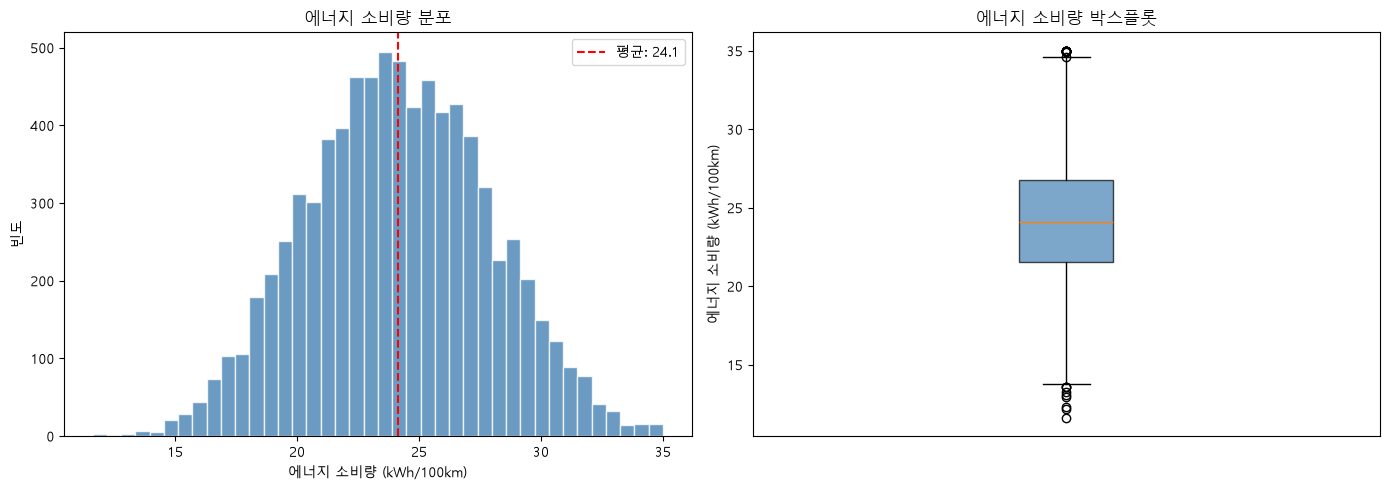

평균: 24.14 kWh/100km
표준편차: 3.74 kWh/100km
최솟값: 11.62 / 최댓값: 35.00


In [5]:
# 타겟 변수 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df['energy_consumption_kwhper100km'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['energy_consumption_kwhper100km'].mean(), color='red', linestyle='--', label=f"평균: {df['energy_consumption_kwhper100km'].mean():.1f}")
axes[0].set_xlabel('에너지 소비량 (kWh/100km)')
axes[0].set_ylabel('빈도')
axes[0].set_title('에너지 소비량 분포')
axes[0].legend()

# 박스플롯
axes[1].boxplot(df['energy_consumption_kwhper100km'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_ylabel('에너지 소비량 (kWh/100km)')
axes[1].set_title('에너지 소비량 박스플롯')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f"평균: {df['energy_consumption_kwhper100km'].mean():.2f} kWh/100km")
print(f"표준편차: {df['energy_consumption_kwhper100km'].std():.2f} kWh/100km")
print(f"최솟값: {df['energy_consumption_kwhper100km'].min():.2f} / 최댓값: {df['energy_consumption_kwhper100km'].max():.2f}")

### 2.2. 주요 특성별 에너지 소비량 관계 분석

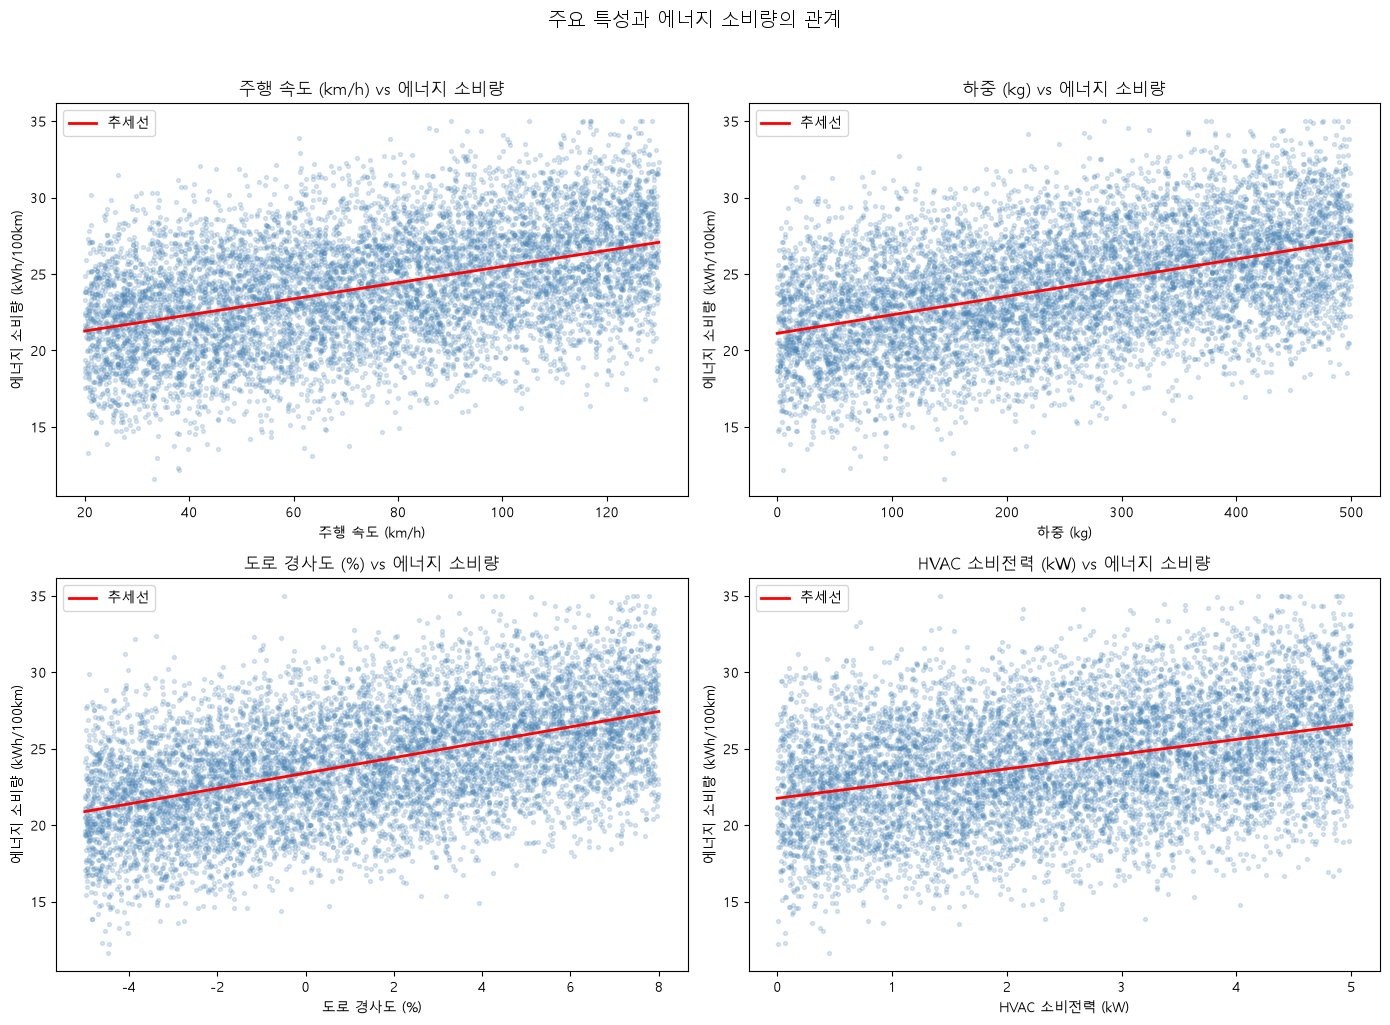

In [6]:
# 주요 특성 4개와 타겟의 산점도
features_to_plot = ['speed_kmh', 'payload_kg', 'road_grade_pct', 'hvac_power_kw']
feature_labels = ['주행 속도 (km/h)', '하중 (kg)', '도로 경사도 (%)', 'HVAC 소비전력 (kW)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features_to_plot, feature_labels)):
    axes[i].scatter(df[feat], df['energy_consumption_kwhper100km'],
                    alpha=0.2, s=8, color='steelblue')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('에너지 소비량 (kWh/100km)')
    axes[i].set_title(f'{label} vs 에너지 소비량')
    # 추세선
    z = np.polyfit(df[feat], df['energy_consumption_kwhper100km'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r-', linewidth=2, label='추세선')
    axes[i].legend()

plt.suptitle('주요 특성과 에너지 소비량의 관계', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

그래프를 보면 꽤 흥미로운 패턴이 보이네요.

- 주행 속도가 높을수록 공기 저항이 커져 에너지 소비가 늘어납니다. 고속 구간의 손실이 뚜렷하네요.
- 하중이 무거울수록 구동에 더 많은 에너지가 필요합니다.
- 도로 경사도는 오르막(+)에서 소비가 급증하고, 내리막(-)에서는 회생제동으로 오히려 에너지를 회수합니다.
- HVAC 소비전력은 냉·난방 가동량만큼 에너지를 직접 끌어다 씁니다.

### 2.3. 기온과 에너지 소비량 관계 분석

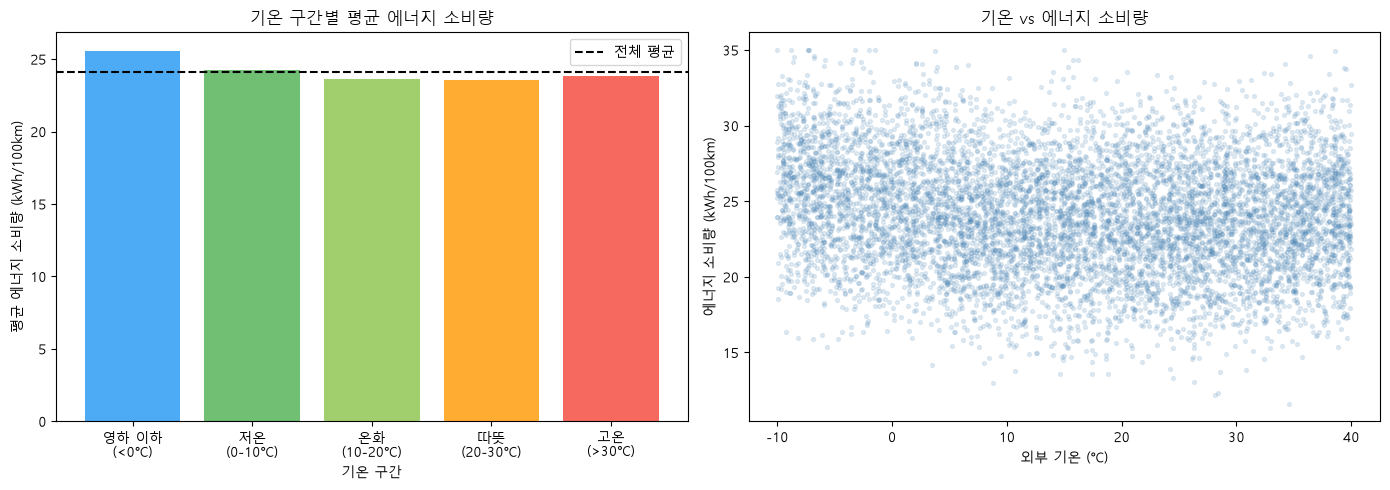

In [7]:
# 기온 구간별 에너지 소비량 분석
df['temp_group'] = pd.cut(df['ambient_temp_C'],
                           bins=[-15, 0, 10, 20, 30, 45],
                           labels=['영하 이하\n(<0°C)', '저온\n(0-10°C)', '온화\n(10-20°C)', '따뜻\n(20-30°C)', '고온\n(>30°C)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 기온 구간별 평균 에너지 소비량
temp_energy = df.groupby('temp_group')['energy_consumption_kwhper100km'].mean()
axes[0].bar(temp_energy.index, temp_energy.values, color=['#2196F3','#4CAF50','#8BC34A','#FF9800','#F44336'], alpha=0.8)
axes[0].set_xlabel('기온 구간')
axes[0].set_ylabel('평균 에너지 소비량 (kWh/100km)')
axes[0].set_title('기온 구간별 평균 에너지 소비량')
axes[0].axhline(df['energy_consumption_kwhper100km'].mean(), color='black', linestyle='--', label='전체 평균')
axes[0].legend()

# 산점도
axes[1].scatter(df['ambient_temp_C'], df['energy_consumption_kwhper100km'],
                alpha=0.15, s=8, color='steelblue')
axes[1].set_xlabel('외부 기온 (°C)')
axes[1].set_ylabel('에너지 소비량 (kWh/100km)')
axes[1].set_title('기온 vs 에너지 소비량')

plt.tight_layout()
plt.show()

# temp_group 컬럼 제거 (이후 학습에서 사용 안 함)
df = df.drop('temp_group', axis=1)

저온(0°C 이하)과 고온(30°C 이상) 양쪽 끝에서 에너지 소비가 늘어나는 U자형 패턴이 보이네요.

- 저온에서는 배터리 성능이 떨어지고 히터까지 돌아가면서 소비가 늘어납니다.
- 고온에서는 에어컨 가동으로 소비가 늘어납니다.
- 10~20°C 정도의 온화한 날씨가 효율이 가장 좋습니다.

### 2.4. 상관관계 분석

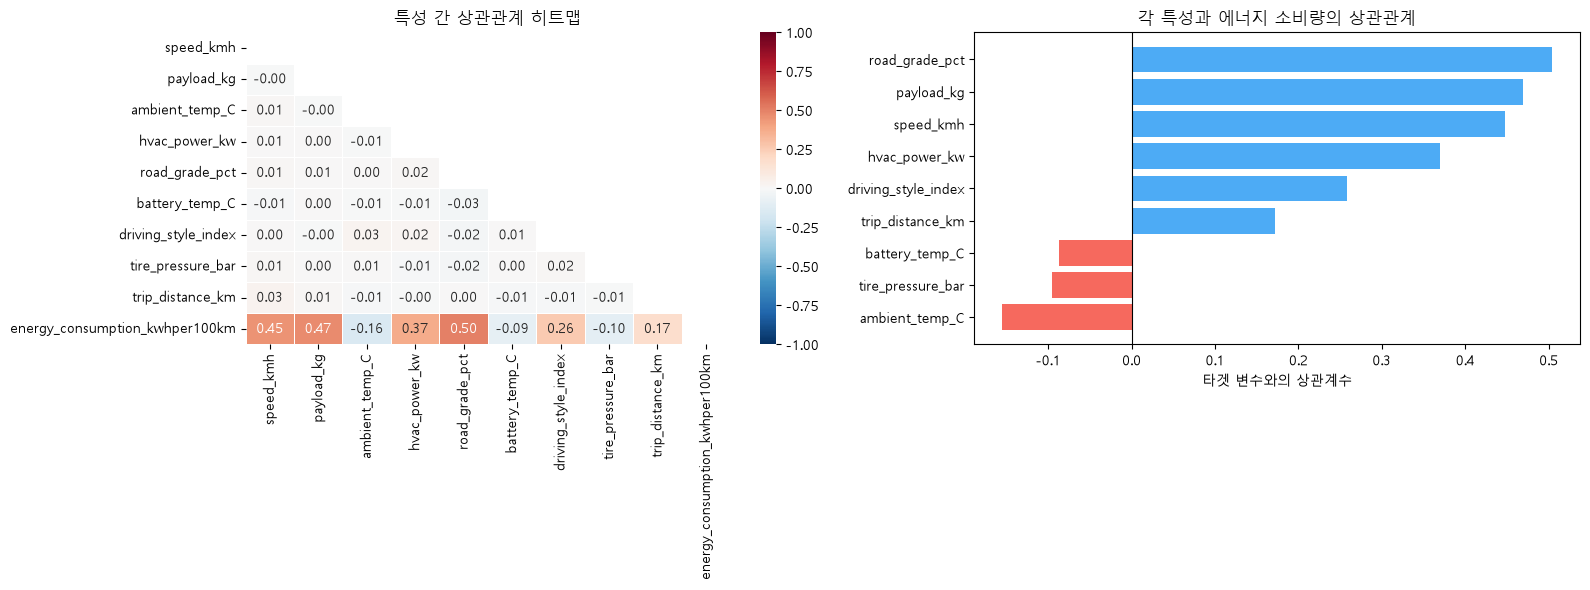


타겟 변수와의 상관관계 (절댓값 내림차순):
road_grade_pct         0.505
payload_kg             0.469
speed_kmh              0.448
hvac_power_kw          0.370
driving_style_index    0.258
trip_distance_km       0.172
ambient_temp_C         0.155
tire_pressure_bar      0.095
battery_temp_C         0.087
Name: energy_consumption_kwhper100km, dtype: float64


In [8]:
# 상관관계 히트맵
corr_matrix = df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 전체 히트맵
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('특성 간 상관관계 히트맵')

# 타겟과의 상관관계
target_corr = corr_matrix['energy_consumption_kwhper100km'].drop('energy_consumption_kwhper100km').sort_values()
colors = ['#F44336' if v < 0 else '#2196F3' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('타겟 변수와의 상관계수')
axes[1].set_title('각 특성과 에너지 소비량의 상관관계')

plt.tight_layout()
plt.show()

print("\n타겟 변수와의 상관관계 (절댓값 내림차순):")
print(target_corr.abs().sort_values(ascending=False).round(3))

상관관계를 보면 다음과 같은 순서로 정리되네요.

- `road_grade_pct`(도로 경사도): 양의 상관관계가 가장 강합니다. 오르막 주행이 에너지 소비에 가장 큰 영향을 줍니다.
- `payload_kg`(하중): 무거울수록 소비가 늘어납니다.
- `speed_kmh`(주행 속도): 속도가 올라가면 공기 저항 때문에 소비가 늘어납니다.
- `hvac_power_kw`(HVAC 전력): 냉·난방 가동량도 꽤 영향을 줍니다.
- `ambient_temp_C`(외부 기온): 기온이 낮을수록 소비가 늘어나는 음의 상관관계입니다.

### 2.5. EDA 요약

지금까지 살펴본 내용을 정리하면 이렇습니다.

1. 에너지 소비는 속도, 하중, 기온, 경사도, HVAC 등 여러 요인이 함께 작용해 정해집니다.
2. 기온의 U자형 관계나 속도의 이차 항처럼 직선으로는 잡히지 않는 비선형 패턴이 섞여 있습니다.
3. 영향력 순서(경사도 > 하중 > 속도)가 전기차 주행 물리와 잘 맞아떨어지네요.
4. 그래서 속도 제곱 항이나 기온의 U자형 변환 같은 특성을 만들어 주면 직선 모델로도 이 패턴을 잡아낼 수 있습니다.

---

## 3. 데이터 전처리

### 3.1. 특성과 타겟 분리

In [9]:
# 특성(X)과 타겟(y) 분리
feature_cols = ['speed_kmh', 'payload_kg', 'ambient_temp_C', 'hvac_power_kw',
                'road_grade_pct', 'battery_temp_C', 'driving_style_index',
                'tire_pressure_bar', 'trip_distance_km']

X = df[feature_cols]
y = df['energy_consumption_kwhper100km']

print(f"특성 데이터 형태: {X.shape}")
print(f"타겟 데이터 형태: {y.shape}")
print(f"\n특성 목록: {list(X.columns)}")

특성 데이터 형태: (8000, 9)
타겟 데이터 형태: (8000,)

특성 목록: ['speed_kmh', 'payload_kg', 'ambient_temp_C', 'hvac_power_kw', 'road_grade_pct', 'battery_temp_C', 'driving_style_index', 'tire_pressure_bar', 'trip_distance_km']


### 3.2. 학습/검증 데이터 분리 및 스케일링

In [10]:
# 학습/검증 데이터 분리 (80:20, 재현성을 위해 random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"학습 데이터: {X_train.shape}")
print(f"검증 데이터: {X_test.shape}")

# 표준화 스케일링 (학습 데이터로만 fit)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("\n스케일링 완료!")
print(f"학습 데이터 평균(스케일 후): {X_train_scaled.mean().mean():.4f} (≈0 이어야 함)")
print(f"학습 데이터 표준편차(스케일 후): {X_train_scaled.std().mean():.4f} (≈1 이어야 함)")

학습 데이터: (6400, 9)
검증 데이터: (1600, 9)

스케일링 완료!
학습 데이터 평균(스케일 후): 0.0000 (≈0 이어야 함)
학습 데이터 표준편차(스케일 후): 1.0001 (≈1 이어야 함)


---

## 4. 머신러닝 모델 비교 및 평가

전기차 에너지 소비량을 예측하기 위해 다양한 특성을 가진 회귀 모델들을 비교해보겠습니다.

평가에는 세 가지 지표를 씁니다. **R²(결정계수)**는 모델이 데이터의 변동성을 얼마나 잘 설명하는지 나타내며, 1에 가까울수록 좋습니다. **RMSE(평균제곱근오차)**는 예측값과 실제값 사이의 평균적인 오차 크기를, **MAE(평균절대오차)**는 오차 절댓값의 평균을 보여주는데, 둘 다 0에 가까울수록 정확한 모델입니다.

### <span style="font-size:24px">[TODO 1] 회귀 모델 3개 학습 & 비교</span>

**할 일:** 회귀 모델 3개를 학습하고, R²가 가장 높은 모델을 찾습니다.

**채점에 쓰이는 변수 (이름 바꾸지 마세요):** `model_results`, `best_model_name`, `best_r2`

**채우는 방법:** 아래 코드에서 `____` 두 곳만 채우면 됩니다.
- 학습 메소드 → `fit`
- 예측 메소드 → `predict`

In [11]:
# ============================================================
# [TODO 1] 회귀 모델 3개를 학습하고 성능을 비교하세요
#   각 줄의 "힌트:"를 보고 ____ 를 채우세요
#   채점 변수(이름 변경 금지): model_results, best_model_name, best_r2
# ============================================================

# 비교할 모델 3개 (제공)
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
}

model_results = {}
for name, model in models.items():
    # [TODO] 모델을 '학습 데이터'로 학습시키세요
    model.fit(X_train_scaled, y_train)                     # 힌트: model.fit(X_train_scaled, y_train)
    

    # [TODO] '테스트 데이터'로 예측하세요
    y_pred = model.predict(X_test_scaled)                 # 힌트: model.predict(X_test_scaled)
    

    # [TODO] R²(결정계수)를 계산하세요  ← 1에 가까울수록 좋음
    r2 = r2_score(y_test, y_pred)              # 힌트: r2_score(y_test, y_pred)

    model_results[name] = {
        'r2':   round(r2, 4),
        'rmse': round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 4),
        'mae':  round(mean_absolute_error(y_test, y_pred), 4),
    }
    print(f"{name}: R2={model_results[name]['r2']:.4f}")

# [TODO] R²가 가장 높은 모델 이름을 고르세요
# 힌트: max(model_results, key=lambda n: model_results[n]['r2'])
best_model_name = max(model_results, key=lambda n: model_results[n]['r2'])

best_r2 = model_results[best_model_name]['r2']
print(f"\n최고 R2 모델: {best_model_name} ({best_r2:.4f})")

LinearRegression: R2=0.9246
Ridge: R2=0.9246


RandomForest: R2=0.8987

최고 R2 모델: LinearRegression (0.9246)


In [12]:
# 모델 성능 비교 출력
results_df = pd.DataFrame(model_results).T
results_df = results_df.round(4)

print("=== 전체 모델 성능 비교 ===")
print(results_df.sort_values('r2', ascending=False))
print()
print(f"통과 조건 (R² ≥ 0.80): {'통과' if best_r2 >= 0.80 else '미통과'}")
print(f"   최고 R²: {best_r2:.4f}")

=== 전체 모델 성능 비교 ===
                      r2    rmse     mae
LinearRegression  0.9246  1.0093  0.8107
Ridge             0.9246  1.0093  0.8107
RandomForest      0.8987  1.1698  0.9301

통과 조건 (R² ≥ 0.80): 통과
   최고 R²: 0.9246


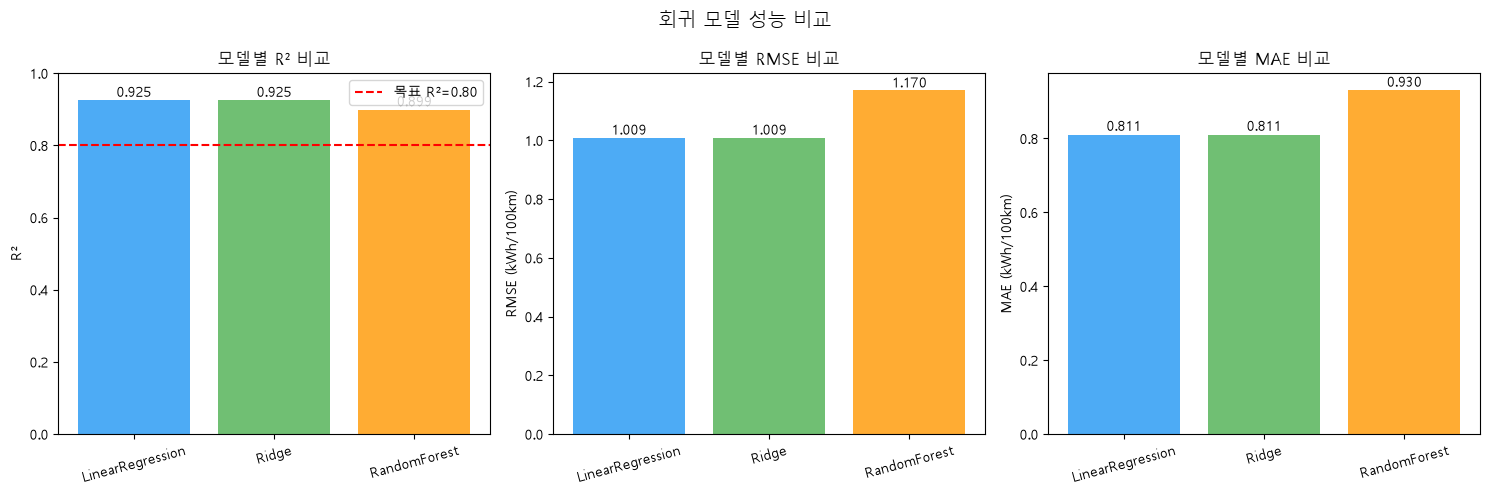

In [13]:
# 모델 성능 시각화
if model_results:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    model_names = list(model_results.keys())
    r2_values = [model_results[m]['r2'] for m in model_names]
    rmse_values = [model_results[m]['rmse'] for m in model_names]
    mae_values = [model_results[m]['mae'] for m in model_names]
    
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
    
    # R² 비교
    bars = axes[0].bar(model_names, r2_values, color=colors[:len(model_names)], alpha=0.8)
    axes[0].axhline(0.80, color='red', linestyle='--', label='목표 R²=0.80')
    axes[0].set_ylabel('R²')
    axes[0].set_title('모델별 R² 비교')
    axes[0].set_ylim(0, 1)
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, r2_values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=10)
    
    # RMSE 비교
    bars = axes[1].bar(model_names, rmse_values, color=colors[:len(model_names)], alpha=0.8)
    axes[1].set_ylabel('RMSE (kWh/100km)')
    axes[1].set_title('모델별 RMSE 비교')
    axes[1].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, rmse_values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=10)
    
    # MAE 비교
    bars = axes[2].bar(model_names, mae_values, color=colors[:len(model_names)], alpha=0.8)
    axes[2].set_ylabel('MAE (kWh/100km)')
    axes[2].set_title('모델별 MAE 비교')
    axes[2].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, mae_values):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{val:.3f}', ha='center', fontsize=10)
    
    plt.suptitle('회귀 모델 성능 비교', fontsize=14)
    plt.tight_layout()
    plt.show()

---

## 5. 특성 공학(Feature Engineering)을 통한 성능 향상

### 5.1. 특성 공학 개념

EDA에서 본 비선형 관계를 직접 컬럼으로 만들어 주면, 직선만 그리는 선형 모델도 그 패턴을 따라갈 수 있습니다. 전기차 에너지 소비에서 써볼 만한 파생 특성은 이런 것들이 있습니다.

- **`speed_squared`**: 공기 저항이 속도의 제곱에 비례하는 점을 반영합니다 (`speed_kmh ** 2`).
- **`cold_stress`**: 영하로 떨어졌을 때의 히터 부하입니다 (`max(0, -ambient_temp_C)`).
- **`heat_stress`**: 30°C를 넘었을 때의 에어컨 부하입니다 (`max(0, ambient_temp_C - 30)`).
- **`total_load`**: 속도와 하중이 함께 커질 때의 상호작용입니다 (`speed_kmh * payload_kg`).

### <span style="font-size:24px">[TODO 2] 특성 공학으로 성능 높이기</span>

**할 일:** 도메인 지식으로 만든 파생 특성을 추가해 모델을 다시 학습하고, R²가 TODO1보다 올라가는지 확인합니다.

**채점에 쓰이는 변수 (이름 바꾸지 마세요):** `best_r2_fe`

**채우는 방법:** 파생 특성은 이미 제공되어 있습니다. 아래 코드에서 `____` 두 곳만 채우면 됩니다.
- 학습 메소드 → `fit`
- 예측 메소드 → `predict`

In [14]:
# ============================================================
# [TODO 2] 파생 특성을 추가해 R²를 개선하세요
#   파생 특성은 제공됩니다. 각 줄의 "힌트:"를 보고 ____ 를 채우세요
#   채점 변수(이름 변경 금지): best_r2_fe
# ============================================================

# 파생 특성 추가 (제공 - 도메인 지식 기반)
target_column = 'energy_consumption_kwhper100km'
df_fe = df.copy()
df_fe['speed_squared'] = df_fe['speed_kmh'] ** 2                       # 공기 저항은 속도의 제곱에 비례
df_fe['cold_stress']   = np.maximum(0, -df_fe['ambient_temp_C'])      # 0°C 이하 히터 부하
df_fe['heat_stress']   = np.maximum(0, df_fe['ambient_temp_C'] - 30)  # 30°C 초과 에어컨 부하
feature_columns_fe = feature_cols + ['speed_squared', 'cold_stress', 'heat_stress']

X_fe = df_fe[feature_columns_fe]
y_fe = df_fe[target_column]
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42)
scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

# 파생 특성으로 재학습 (제공된 모델, ____만 채우기)
model_fe = LinearRegression()

# [TODO] 파생 특성 데이터로 학습시키세요
model_fe.fit(X_train_fe_scaled, y_train_fe)                              # 힌트: model_fe.fit(X_train_fe_scaled, y_train_fe)

# [TODO] 예측하세요
y_pred_fe = model_fe.predict(X_test_fe_scaled)                  # 힌트: model_fe.predict(X_test_fe_scaled)

# [TODO] R²를 계산하세요
best_r2_fe = round(r2_score(y_test_fe, y_pred_fe), 4)               # 힌트: round(r2_score(y_test_fe, y_pred_fe), 4)

print(f"특성 공학 전 R2: {best_r2:.4f}  ->  후 R2: {best_r2_fe:.4f}")

특성 공학 전 R2: 0.9246  ->  후 R2: 0.9464


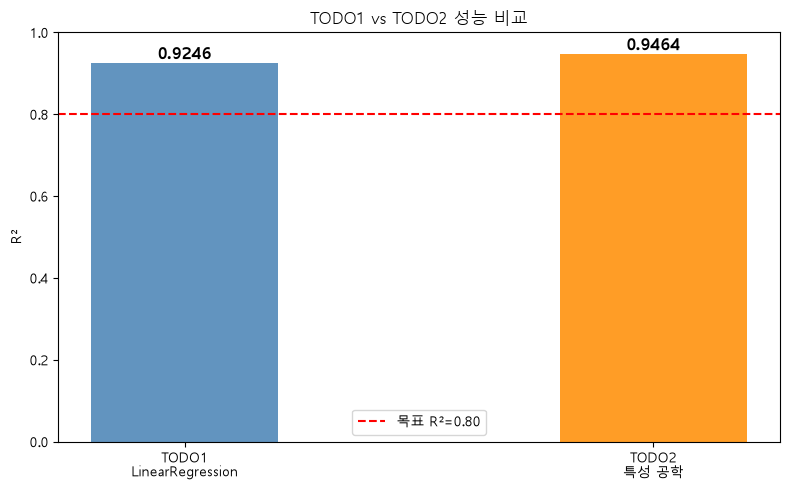


특성 공학 적용 결과:
  이전 최고 R²: 0.9246 (LinearRegression)
  특성 공학 후 R²: 0.9464
  개선량: +0.0218


In [15]:
# TODO1 vs TODO2 성능 비교 시각화
fig, ax = plt.subplots(figsize=(8, 5))

methods = [f'TODO1\n{best_model_name}', 'TODO2\n특성 공학']
r2_compare = [best_r2, best_r2_fe]
colors_cmp = ['steelblue', 'darkorange']

bars = ax.bar(methods, r2_compare, color=colors_cmp, alpha=0.85, width=0.4)
ax.axhline(0.80, color='red', linestyle='--', label='목표 R²=0.80')
ax.set_ylabel('R²')
ax.set_title('TODO1 vs TODO2 성능 비교')
ax.set_ylim(0, 1)
ax.legend()
for bar, val in zip(bars, r2_compare):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n특성 공학 적용 결과:")
print(f"  이전 최고 R²: {best_r2:.4f} ({best_model_name})")
print(f"  특성 공학 후 R²: {best_r2_fe:.4f}")
print(f"  개선량: {best_r2_fe - best_r2:+.4f}")

---

## <span style="font-size:24px">실습 결과 제출</span>

실습 중간 `[TODO]` 코드들을 모두 잘 작성하셨나요?

아래 코드를 실행 후, 오른쪽 상단의 **제출 버튼**을 클릭해 주세요.

**주의 사항**

- 아래 코드를 실행하기 전 `[TODO]` 빈칸을 모두 잘 작성하였는지, 통과 조건을 만족하였는지 반드시 확인해 주세요.
- `[TODO]`에서 지정된 변수명이나 아래 코드를 임의로 수정할 경우, 채점이 정상적으로 이루어지지 않습니다.

통과 조건도 다시 한 번 확인해 주세요.
- TODO1: `model_results`에 모델 3종의 결과가 담겨 있고, 최고 R²(`best_r2`)가 0.80 이상
- TODO2: `best_r2_fe`가 정의되어 있고, 특성 공학 후 R²가 TODO1보다 향상됨

In [16]:
import json

student_answers = {}
student_answers['model_results'] = model_results if 'model_results' in locals() else {}
student_answers['best_model_name'] = best_model_name if 'best_model_name' in locals() else None
student_answers['best_r2'] = float(best_r2) if 'best_r2' in locals() else None
student_answers['best_r2_fe'] = float(best_r2_fe) if 'best_r2_fe' in locals() else None
student_answers['data_shape'] = list(df.shape) if 'df' in locals() else None
student_answers['feature_count'] = len(X.columns) if 'X' in locals() else None

with open('result.json', 'w', encoding='utf-8') as f:
    json.dump(student_answers, f, ensure_ascii=False, indent=2)

print("result.json 저장 완료!")

result.json 저장 완료!


---

## 6. 학습 모델 저장

`model` 폴더를 만들고, TODO1에서 학습한 `LinearRegression` 모델을 파일로 저장합니다.

In [17]:
import os
import joblib

# model 폴더 생성
os.makedirs('model', exist_ok=True)

# TODO1에서 학습한 LinearRegression 모델과 스케일러 저장
joblib.dump(models['LinearRegression'], 'model/linear_regression_model.pkl')
joblib.dump(scaler, 'model/scaler.pkl')

print("모델 저장 완료!")
print(" - model/linear_regression_model.pkl")
print(" - model/scaler.pkl")

모델 저장 완료!
 - model/linear_regression_model.pkl
 - model/scaler.pkl
